# 순환 신경망 기반 감성 분석 (무신사 뷰티 리뷰)
1. 데이터 준비
2. 모델 구조 및 학습 설계
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터 준비

### 1-1. 데이터 로딩

In [1]:
import pandas as pd

datafile = './musinsa_beauty_TOTAL.csv'
review_df = pd.read_csv(datafile, encoding='utf-8-sig', low_memory=False)
print(f'전체 데이터: {len(review_df):,}건')
review_df.head()

전체 데이터: 231,029건


,product_id,product_name,brand_name,price,original_price,discount_rate,product_url,nickname,date,rating,skin_tone,skin_type,skin_raw,satisfaction,purchase_option,review_text,helpful,crawled_at,sentiment
0,6330687,저분자 히알루론산 딥 토너 500ml,thelabbyblancdoux,28900,37000,22,https://www.musinsa.com/products/6330687,너굴너구울,26.05.04,5.0,가을 웜톤,복합성 · 유수분조절 · 모공 · 여드름,가을 웜톤 · 복합성 · 유수분조절 · 모공 · 여드름,보습력 높음 · 흡수력 좋음 · 자극여부 전혀없음 · 재구매 의사 있음,NONE,이 토너는 뭐 매일매일 하루에 두번씩은 씁니다\n자극 없고 촉촉하고\n세럼 바르기 ...,4,2026-05-15 22:55,부정
1,6330687,저분자 히알루론산 딥 토너 500ml,thelabbyblancdoux,28900,37000,22,https://www.musinsa.com/products/6330687,너굴너구울,26.04.26,5.0,가을 웜톤,복합성 · 유수분조절 · 모공 · 여드름,가을 웜톤 · 복합성 · 유수분조절 · 모공 · 여드름,보습력 매우 높음 · 흡수력 매우 좋음 · 자극여부 전혀없음,NONE,피부특징🔥 티존에 기름이 있고 다른 부분들은,2,2026-05-15 22:55,중립
2,6330687,저분자 히알루론산 딥 토너 500ml,thelabbyblancdoux,28900,37000,22,https://www.musinsa.com/products/6330687,530415,2일 전,5.0,봄 웜톤,건성 · 유수분조절,봄 웜톤 · 건성 · 유수분조절,보습력 매우 높음 · 흡수력 매우 좋음 · 자극여부 전혀없음,NONE,촉촉하고 발림성도 좋고 끈적이지 않아 제일 좋은것 같아요,0,2026-05-15 22:55,부정
3,6330687,저분자 히알루론산 딥 토너 500ml,thelabbyblancdoux,28900,37000,22,https://www.musinsa.com/products/6330687,물끼-,26.05.02,5.0,겨울 쿨톤,복합성 · 진정/보습 · 모공 · 유수분조절,겨울 쿨톤 · 복합성 · 진정/보습 · 모공 · 유수분조절,보습력 매우 높음 · 흡수력 매우 좋음 · 자극여부 전혀없음,NONE,꾸준히 사용하던 제품이고 끈적임없고 발림성이 좋고 흡수력도 좋아서 4계절 내내 사용...,0,2026-05-15 22:55,부정
4,6330687,저분자 히알루론산 딥 토너 500ml,thelabbyblancdoux,28900,37000,22,https://www.musinsa.com/products/6330687,베이비베비,26.05.01,5.0,겨울 쿨톤,복합성 · 모공 · 여드름 · 탄력,겨울 쿨톤 · 복합성 · 모공 · 여드름 · 탄력,보습력 높음 · 흡수력 매우 좋음 · 자극여부 전혀없음,NONE,저분자 히알루로산 토너나 앰플 알아보다가\n더랩바이블랑두 제품이 좋다고 해서\n바로...,0,2026-05-15 22:55,중립


In [2]:
# sentiment 컬럼 확인
review_df['sentiment'].value_counts()

sentiment
긍정    114927
중립     65513
부정     50589
Name: count, dtype: int64

In [3]:
# 중립 제외 → 긍정/부정 이진 분류
# 교수님 노트북과 동일하게 label: 부정=0, 긍정=1
review_df = review_df[review_df['sentiment'] != '중립'].copy()
review_df['label'] = review_df['sentiment'].map({'긍정': 1, '부정': 0})

# review_text를 document로 통일 (교수님 코드와 호환)
review_df = review_df[['review_text', 'label']].rename(columns={'review_text': 'document'})
print(f'분류 대상: {len(review_df):,}건')
review_df['label'].value_counts()

분류 대상: 165,516건


label
1    114927
0     50589
Name: count, dtype: int64

### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [4]:
review_df.isnull().sum()

document    0
label       0
dtype: int64

In [5]:
review_df.dropna(inplace=True)
review_df.isnull().sum()

document    0
label       0
dtype: int64

#### 1-2-2. 정제 (한글과 공백만 남기기)

In [6]:
import re

review_df['clean_review'] = review_df['document'].apply(lambda x: re.sub('[^ 가-힣]+', ' ', str(x)))
review_df['clean_review'] = review_df['clean_review'].apply(lambda x: re.sub('^ +', '', x))
review_df['clean_review'] = review_df['clean_review'].replace('', None)

print(f'결측치: {review_df.clean_review.isnull().sum()}건')
review_df.dropna(subset=['clean_review'], inplace=True)
review_df.head()

결측치: 0건


,document,label,clean_review
0,이 토너는 뭐 매일매일 하루에 두번씩은 씁니다\n자극 없고 촉촉하고\n세럼 바르기 ...,0,이 토너는 뭐 매일매일 하루에 두번씩은 씁니다 자극 없고 촉촉하고 세럼 바르기 전에...
2,촉촉하고 발림성도 좋고 끈적이지 않아 제일 좋은것 같아요,0,촉촉하고 발림성도 좋고 끈적이지 않아 제일 좋은것 같아요
3,꾸준히 사용하던 제품이고 끈적임없고 발림성이 좋고 흡수력도 좋아서 4계절 내내 사용...,0,꾸준히 사용하던 제품이고 끈적임없고 발림성이 좋고 흡수력도 좋아서 계절 내내 사용...
5,촉촉한데 너무 무겁지는 않고 흡수도 잘되요. 수부지가 사계절에 쓰기 좋은거 같아요.,1,촉촉한데 너무 무겁지는 않고 흡수도 잘되요 수부지가 사계절에 쓰기 좋은거 같아요
6,흡수 빠르고 엄청 촉촉한데 안 끈적이고 그냥 촤고..,0,흡수 빠르고 엄청 촉촉한데 안 끈적이고 그냥 촤고


#### 1-2-3. 중복치 제거

In [7]:
print(f'중복: {review_df.clean_review.duplicated().sum()}건')
review_df.drop_duplicates(subset=['clean_review'], inplace=True)
print(f'중복 제거 후: {len(review_df):,}건')
review_df['label'].value_counts()

중복: 5275건
중복 제거 후: 160,241건


label
1    110934
0     49307
Name: count, dtype: int64

#### 1-2-4. 형태소 분석 (토큰화)
※ 시간이 오래 걸립니다 (10~30분)

In [8]:
from konlpy.tag import Okt
from tqdm import tqdm
tqdm.pandas()

review_df['tokens'] = review_df['clean_review'].progress_apply(Okt().morphs)
review_df['tokens_str'] = review_df['tokens'].apply(lambda x: ' '.join(x))
review_df.head()

100%|██████████| 160241/160241 [05:41<00:00, 468.91it/s]


,document,label,clean_review,tokens,tokens_str
0,이 토너는 뭐 매일매일 하루에 두번씩은 씁니다\n자극 없고 촉촉하고\n세럼 바르기 ...,0,이 토너는 뭐 매일매일 하루에 두번씩은 씁니다 자극 없고 촉촉하고 세럼 바르기 전에...,"[이, 토너, 는, 뭐, 매, 일, 매일, 하루, 에, 두, 번, 씩, 은, 씁니다...",이 토너 는 뭐 매 일 매일 하루 에 두 번 씩 은 씁니다 자극 없고 촉촉하고 세 ...
2,촉촉하고 발림성도 좋고 끈적이지 않아 제일 좋은것 같아요,0,촉촉하고 발림성도 좋고 끈적이지 않아 제일 좋은것 같아요,"[촉촉하고, 발림, 성도, 좋고, 끈, 적, 이지, 않아, 제일, 좋은, 것, 같아요]",촉촉하고 발림 성도 좋고 끈 적 이지 않아 제일 좋은 것 같아요
3,꾸준히 사용하던 제품이고 끈적임없고 발림성이 좋고 흡수력도 좋아서 4계절 내내 사용...,0,꾸준히 사용하던 제품이고 끈적임없고 발림성이 좋고 흡수력도 좋아서 계절 내내 사용...,"[꾸준히, 사용, 하던, 제품, 이고, 끈, 적임, 없고, 발림, 성, 이, 좋고,...",꾸준히 사용 하던 제품 이고 끈 적임 없고 발림 성 이 좋고 흡수 력 도 좋아서 계...
5,촉촉한데 너무 무겁지는 않고 흡수도 잘되요. 수부지가 사계절에 쓰기 좋은거 같아요.,1,촉촉한데 너무 무겁지는 않고 흡수도 잘되요 수부지가 사계절에 쓰기 좋은거 같아요,"[촉촉한데, 너무, 무겁지는, 않고, 흡수, 도, 잘, 되요, 수, 부지, 가, 사...",촉촉한데 너무 무겁지는 않고 흡수 도 잘 되요 수 부지 가 사계절 에 쓰기 좋은 거...
6,흡수 빠르고 엄청 촉촉한데 안 끈적이고 그냥 촤고..,0,흡수 빠르고 엄청 촉촉한데 안 끈적이고 그냥 촤고,"[흡수, 빠르고, 엄청, 촉촉한데, 안, 끈, 적, 이고, 그냥, 촤, 고]",흡수 빠르고 엄청 촉촉한데 안 끈 적 이고 그냥 촤 고


In [9]:
# 전처리 결과 저장 (다음에 다시 안 해도 되도록)
review_df.to_csv('./musinsa_beauty_preprocessed.csv', encoding='utf-8-sig', index=False)
print('저장 완료')

저장 완료


### 1-3. 데이터 분리

학습: 144,216건 / 테스트: 16,025건


C:\Users\User\anaconda3\envs\aiservice26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\envs\aiservice26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\envs\aiservice26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\envs\aiservice26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\envs\aiservice26\lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3

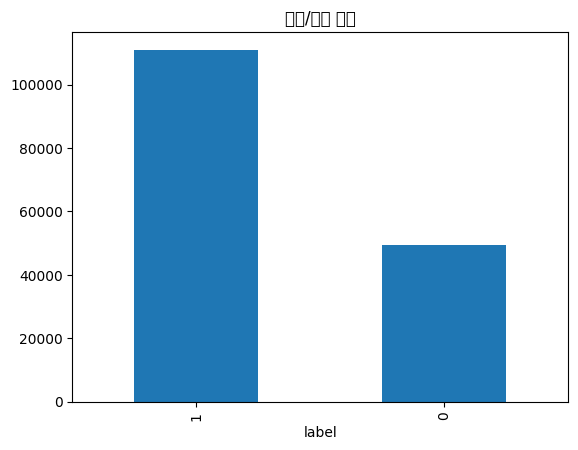

In [10]:
from sklearn.model_selection import train_test_split

review_list = list(review_df['tokens_str'])
label_list  = list(review_df['label'])

review_df['label'].value_counts().plot(kind='bar', title='긍정/부정 분포')

review_train, review_test, label_train, label_test = train_test_split(
    review_list, label_list, test_size=0.1, stratify=label_list, random_state=42
)
print(f'학습: {len(review_train):,}건 / 테스트: {len(review_test):,}건')

### 1-4. 학습 데이터 준비

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer

# 단어 수 확인용
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(review_train)
print(f'전체 단어 수: {len(test_tokenizer.word_index):,}개')

전체 단어 수: 53,048개


In [12]:
vocab_size = 40000
num_words  = vocab_size + 1
tokenizer  = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(review_train)

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Integer Encoding
encoded_train = tokenizer.texts_to_sequences(review_train)

# 길이 0인 리뷰 제거
null_index    = [i for i, r in enumerate(encoded_train) if len(r) < 1]
new_review_train = [r for i, r in enumerate(encoded_train) if i not in null_index]
new_label_train  = [l for i, l in enumerate(label_train)  if i not in null_index]
print(f'유효 학습 데이터: {len(new_review_train):,}건')

# 리뷰 길이 분포 확인
import pandas as pd
len_df = pd.DataFrame([len(r) for r in new_review_train])
print(len_df.describe())

# Padding
max_len = 100  # 뷰티 리뷰는 영화리뷰보다 길어서 100으로 설정
train_X = pad_sequences(new_review_train, maxlen=max_len)
print(f'train_X shape: {train_X.shape}')

유효 학습 데이터: 144,216건
                   0
count  144216.000000
mean       18.996457
std        15.894819
min         1.000000
25%        11.000000
50%        14.000000
75%        21.000000
max       260.000000
train_X shape: (144216, 100)


In [14]:
from tensorflow.keras.utils import to_categorical

train_y = to_categorical(new_label_train)
train_y[:3]

array([[0., 1.],
       [0., 1.],
       [1., 0.]])

### 1-5. 테스트 데이터 준비

In [15]:
encoded_test = tokenizer.texts_to_sequences(review_test)
null_index   = [i for i, r in enumerate(encoded_test) if len(r) == 0]
new_review_test = [r for i, r in enumerate(encoded_test) if i not in null_index]
new_label_test  = [l for i, l in enumerate(label_test)  if i not in null_index]

test_X = pad_sequences(new_review_test, maxlen=max_len)
test_y = to_categorical(new_label_test)
print(f'test_X shape: {test_X.shape}')

test_X shape: (16025, 100)


## 2. 모델 구축 및 컴파일

In [16]:
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

embedding_dim = 32
lstm_units    = 64
dense_units   = 16
output_units  = 2

model = Sequential([
    Embedding(num_words, embedding_dim, input_length=max_len),
    LSTM(lstm_units),
    Dense(dense_units, activation='tanh'),
    Dense(output_units, activation='softmax')
])
model.summary()

C:\Users\User\anaconda3\envs\aiservice26\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer=RMSprop(learning_rate=0.001))

## 3. 모델 학습

In [18]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

os.makedirs('./model', exist_ok=True)
checkpoint_file = './model/best_model_beauty.keras'

es = EarlyStopping(monitor='val_loss', mode='min', patience=3, verbose=1)
mc = ModelCheckpoint(checkpoint_file, monitor='val_loss', save_best_only=True)

history = model.fit(
    train_X, train_y,
    epochs=20, batch_size=128,
    validation_split=0.1,
    callbacks=[es, mc]
)

Epoch 1/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 75s 72ms/step - accuracy: 0.8794 - loss: 0.2757 - val_accuracy: 0.9824 - val_loss: 0.0633
Epoch 2/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.9859 - loss: 0.0515 - val_accuracy: 0.9870 - val_loss: 0.0538
Epoch 3/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 60s 59ms/step - accuracy: 0.9908 - loss: 0.0357 - val_accuracy: 0.9864 - val_loss: 0.0455
Epoch 4/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 96s 72ms/step - accuracy: 0.9927 - loss: 0.0292 - val_accuracy: 0.9899 - val_loss: 0.0364
Epoch 5/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 73s 72ms/step - accuracy: 0.9947 - loss: 0.0210 - val_accuracy: 0.9914 - val_loss: 0.0393
Epoch 6/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9954 - loss: 0.0181 - val_accuracy: 0.9911 - val_loss: 0.0341
Epoch 7/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 71s 70ms/step - accuracy: 0.9964 - loss: 0.0140 - val_accuracy: 0.9916 - val_loss: 0.0349
Epoch 8/20
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.9972 -

## 4. 모델 평가

In [19]:
from tensorflow.keras.models import load_model

model.load_weights(checkpoint_file)
loss, acc = model.evaluate(test_X, test_y)
print(f'손실: {loss:.4f} / 정확도: {acc:.4f}')

501/501 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9924 - loss: 0.0303
손실: 0.0301 / 정확도: 0.9927


In [20]:
import numpy as np
from sklearn.metrics import classification_report

preds  = model.predict(test_X)
result = [np.argmax(p) for p in preds]

print(classification_report(new_label_test, result, target_names=['부정', '긍정']))

501/501 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
              precision    recall  f1-score   support

          부정       0.99      0.98      0.99      4931
          긍정       0.99      1.00      0.99     11094

    accuracy                           0.99     16025
   macro avg       0.99      0.99      0.99     16025
weighted avg       0.99      0.99      0.99     16025



## 5. 예측

In [21]:
from konlpy.tag import Okt

def analyze_sentiment(text):
    tokens       = Okt().morphs(re.sub('[^ 가-힣]+', ' ', text))
    encoded      = tokenizer.texts_to_sequences([tokens])
    X            = pad_sequences(encoded, maxlen=max_len)
    preds        = model.predict(X, verbose=0)
    labels       = ['부정', '긍정']
    result_index = np.argmax(preds[0])
    return labels[result_index], preds[0][result_index]

# 테스트
reviews = [
    '촉촉하고 발림성도 좋아서 재구매 했어요',
    '피부에 트러블이 생겨서 너무 실망이에요',
    '끈적임이 심하고 냄새도 별로예요',
    '보습력이 뛰어나고 흡수도 빨라요 강추!',
    '자극이 있어서 환불했습니다'
]

for review in reviews:
    result, prob = analyze_sentiment(review)
    print(f'{review[:30]} --> {result} ({prob*100:.1f}%)')

촉촉하고 발림성도 좋아서 재구매 했어요 --> 긍정 (100.0%)
피부에 트러블이 생겨서 너무 실망이에요 --> 부정 (100.0%)
끈적임이 심하고 냄새도 별로예요 --> 부정 (100.0%)
보습력이 뛰어나고 흡수도 빨라요 강추! --> 긍정 (100.0%)
자극이 있어서 환불했습니다 --> 부정 (100.0%)


## 6. 배포 (모델 저장)

In [22]:
import joblib

model.save('./model/sa_model_beauty.keras')
joblib.dump(tokenizer, './model/sa_tokenizer_beauty.pkl')
print('모델 저장 완료')

모델 저장 완료
